<a href="https://colab.research.google.com/github/Gaurav-Kanse/ecommerce-sales-customer-analytics/blob/main/Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [31]:
df = pd.read_excel("Online Retail.xlsx")

In [32]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [33]:
required_cols = [
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "Country"
]


missing_required = [
    c for c in required_cols
    if c not in df.columns
]

if missing_required:
    raise ValueError(
        f"Required columns missing: {missing_required}. "
        f"Available columns: {df.columns.tolist()}"
    )

rows_before = len(df)

df["InvoiceNo"] = df["InvoiceNo"].astype("string").str.strip()
df["StockCode"] = df["StockCode"].astype("string").str.strip()
df["Country"] = df["Country"].astype("string").str.strip()

if "Description" in df.columns:
    df["Description"] = df["Description"].astype("string").str.strip()

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

df["Quantity"] = pd.to_numeric(
    df["Quantity"],
    errors="coerce"
)

df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"],
    errors="coerce"
)

if "CustomerID" in df.columns:
    df["CustomerID"] = pd.to_numeric(
        df["CustomerID"],
        errors="coerce"
    )

duplicates_removed = int(df.duplicated().sum())
df = df.drop_duplicates()

df = df.dropna(
    subset=[
        "InvoiceNo",
        "StockCode",
        "InvoiceDate",
        "Quantity",
        "UnitPrice",
        "Country"
    ]
)

In [34]:
df["IsCancelled"] = df["InvoiceNo"].str.startswith(
    "C",
    na=False
)

df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)

df["Week"] = df["InvoiceDate"].dt.to_period("W").astype(str)

df["Hour"] = df["InvoiceDate"].dt.hour

df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()


In [35]:
print("DATA CLEANING SUMMARY")
print("=" * 40)

print(f"Original rows: {rows_before:,}")

print(f"Duplicates removed: {duplicates_removed:,}")

print(f"Rows after cleaning: {len(df):,}")

print(
    f"Cancelled invoice lines: "
    f"{df['IsCancelled'].sum():,}"
)

print(
    f"Negative quantity rows: "
    f"{(df['Quantity'] < 0).sum():,}"
)

print(
    f"Non-positive unit prices: "
    f"{(df['UnitPrice'] <= 0).sum():,}"
)

if "CustomerID" in df.columns:
    print(
        f"Missing CustomerIDs: "
        f"{df['CustomerID'].isna().sum():,}"
    )

display(df.head())

DATA CLEANING SUMMARY
Original rows: 541,909
Duplicates removed: 5,268
Rows after cleaning: 536,641
Cancelled invoice lines: 9,251
Negative quantity rows: 10,587
Non-positive unit prices: 2,512
Missing CustomerIDs: 135,037


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,Revenue,YearMonth,Week,Hour,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30,2010-12,2010-11-29/2010-12-05,8,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12,2010-11-29/2010-12-05,8,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00,2010-12,2010-11-29/2010-12-05,8,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12,2010-11-29/2010-12-05,8,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34,2010-12,2010-11-29/2010-12-05,8,Wednesday


In [36]:
sales = df.loc[
    (~df["IsCancelled"]) &
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()

sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]
sales["OrderDate"] = sales["InvoiceDate"].dt.date

n_invoices = sales["InvoiceNo"].nunique()
n_customers = sales["CustomerID"].nunique() if "CustomerID" in sales.columns else np.nan
total_revenue = sales["Revenue"].sum()
total_units = sales["Quantity"].sum()
avg_order_value = sales.groupby("InvoiceNo")["Revenue"].sum().mean()
avg_unit_price = sales["UnitPrice"].mean()

kpis = pd.DataFrame({
    "Metric": [
        "Sales line items", "Unique invoices/orders", "Unique identified customers",
        "Total gross sales revenue", "Total units sold", "Average order value",
        "Average unit price"
    ],
    "Value": [
        len(sales), n_invoices, n_customers, total_revenue, total_units,
        avg_order_value, avg_unit_price
    ]
})
display(kpis)

,Metric,Value
0,Sales line items,5.248780e+05
1,Unique invoices/orders,1.996000e+04
2,Unique identified customers,4.338000e+03
3,Total gross sales revenue,1.064211e+07
4,Total units sold,5.572420e+06
5,Average order value,5.331719e+02
6,Average unit price,3.922573e+00


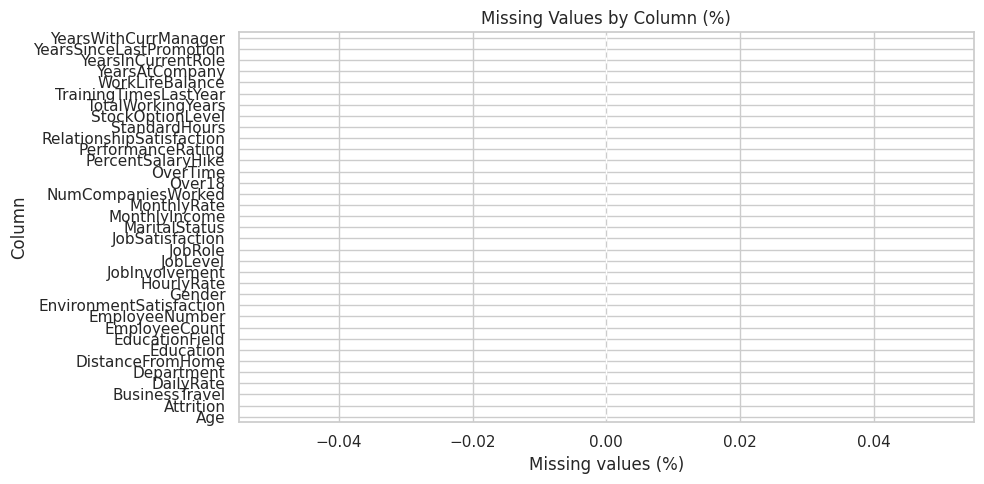

Rows with a known CustomerID: 74.84%


In [37]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_summary["missing_percent"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Missing Values by Column (%)")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("Column")
plt.tight_layout()
plt.show()

if "CustomerID" in df.columns:
    customer_coverage = df["CustomerID"].notna().mean() * 100
    print(f"Rows with a known CustomerID: {customer_coverage:.2f}%")

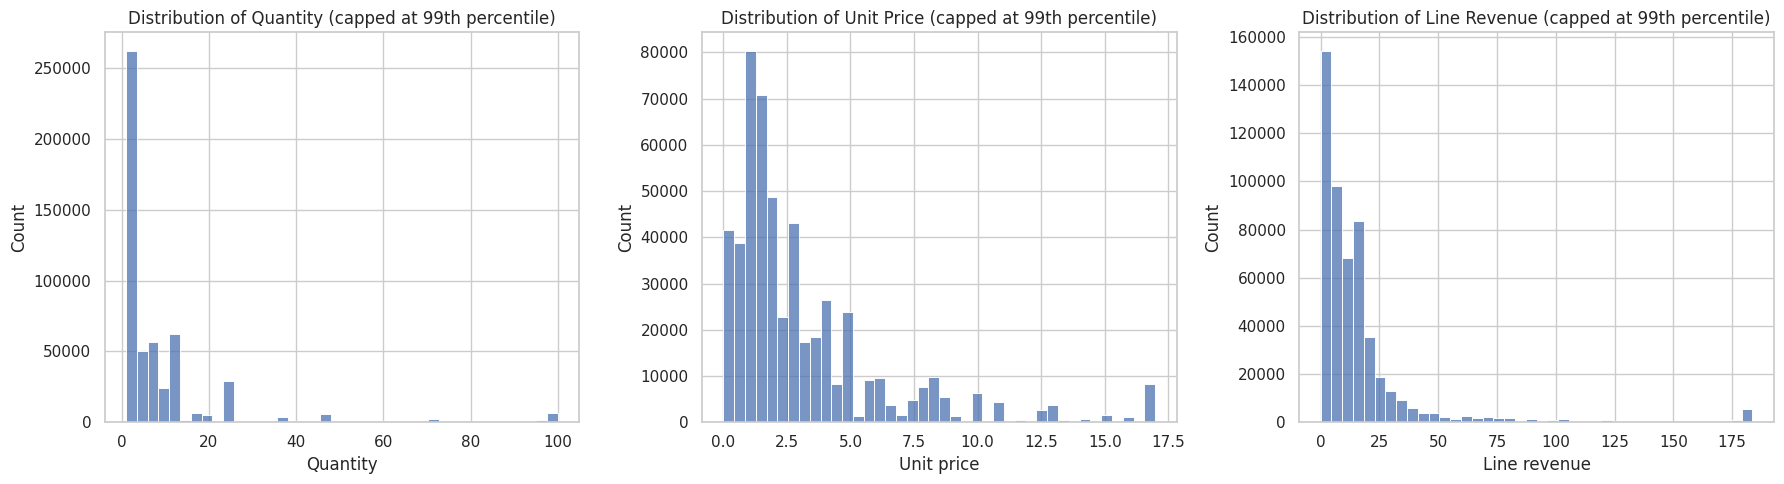

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(sales["Quantity"].clip(upper=sales["Quantity"].quantile(0.99)), bins=40, ax=axes[0])
axes[0].set_title("Distribution of Quantity (capped at 99th percentile)")
axes[0].set_xlabel("Quantity")

sns.histplot(sales["UnitPrice"].clip(upper=sales["UnitPrice"].quantile(0.99)), bins=40, ax=axes[1])
axes[1].set_title("Distribution of Unit Price (capped at 99th percentile)")
axes[1].set_xlabel("Unit price")

sns.histplot(sales["Revenue"].clip(upper=sales["Revenue"].quantile(0.99)), bins=40, ax=axes[2])
axes[2].set_title("Distribution of Line Revenue (capped at 99th percentile)")
axes[2].set_xlabel("Line revenue")

plt.tight_layout()
plt.show()

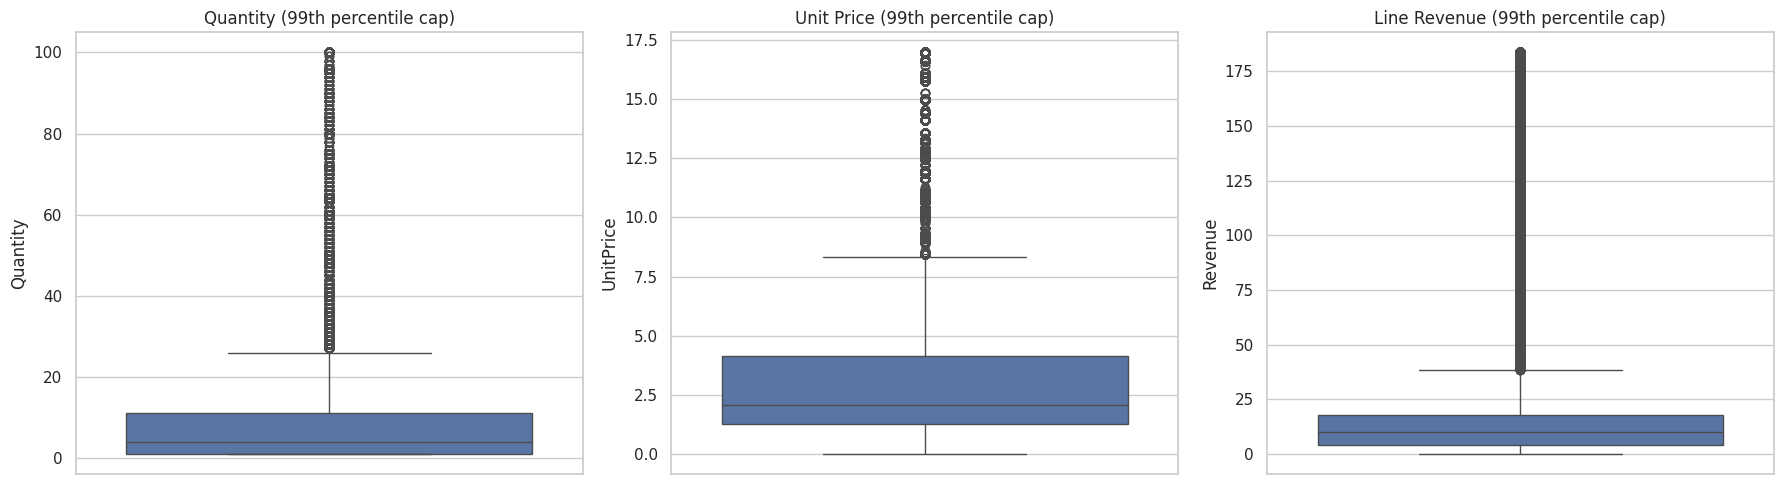

,column,p25,median,p75,p99,max
0,Quantity,1.00,4.00,11.00,100.00,80995.00
1,UnitPrice,1.25,2.08,4.13,16.98,13541.33
2,Revenue,3.90,9.92,17.70,183.60,168469.60


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=sales["Quantity"].clip(upper=sales["Quantity"].quantile(0.99)), ax=axes[0])
axes[0].set_title("Quantity (99th percentile cap)")

sns.boxplot(y=sales["UnitPrice"].clip(upper=sales["UnitPrice"].quantile(0.99)), ax=axes[1])
axes[1].set_title("Unit Price (99th percentile cap)")

sns.boxplot(y=sales["Revenue"].clip(upper=sales["Revenue"].quantile(0.99)), ax=axes[2])
axes[2].set_title("Line Revenue (99th percentile cap)")

plt.tight_layout()
plt.show()

outlier_summary = pd.DataFrame({
    "column": ["Quantity", "UnitPrice", "Revenue"],
    "p25": [sales[c].quantile(.25) for c in ["Quantity", "UnitPrice", "Revenue"]],
    "median": [sales[c].median() for c in ["Quantity", "UnitPrice", "Revenue"]],
    "p75": [sales[c].quantile(.75) for c in ["Quantity", "UnitPrice", "Revenue"]],
    "p99": [sales[c].quantile(.99) for c in ["Quantity", "UnitPrice", "Revenue"]],
    "max": [sales[c].max() for c in ["Quantity", "UnitPrice", "Revenue"]],
})
display(outlier_summary)

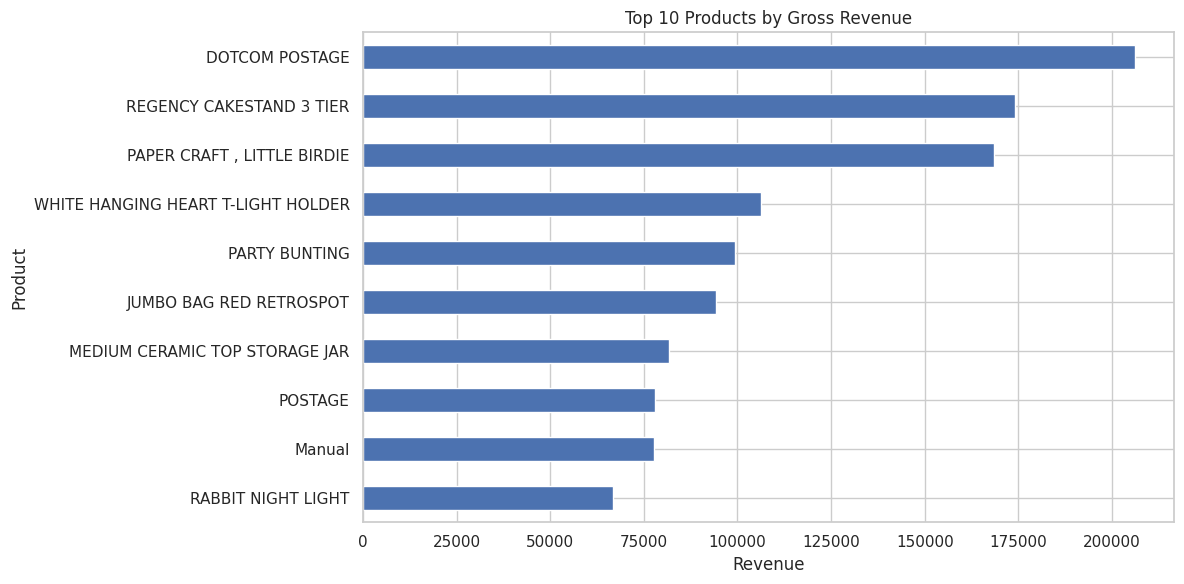

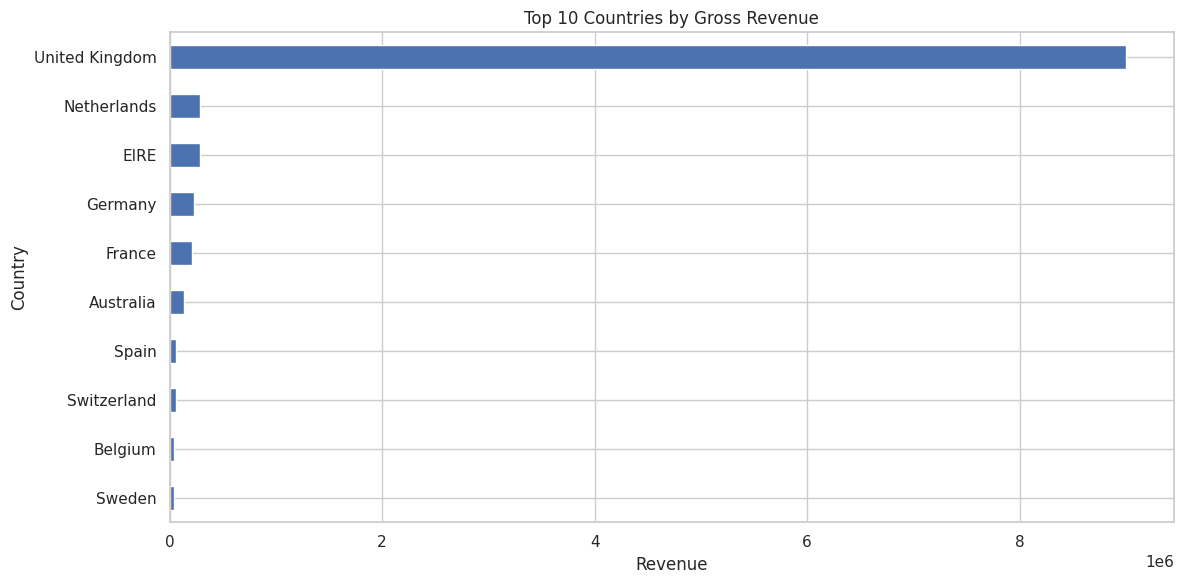

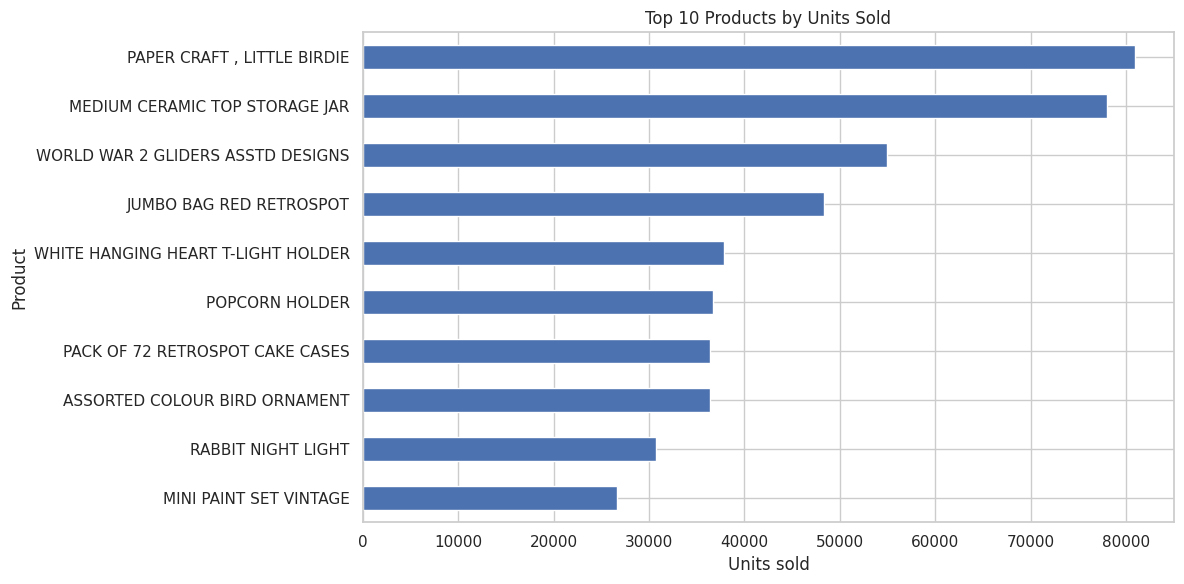

Top 10 products by revenue:


,Revenue
Description,
DOTCOM POSTAGE,206248.77
REGENCY CAKESTAND 3 TIER,174156.54
"PAPER CRAFT , LITTLE BIRDIE",168469.60
WHITE HANGING HEART T-LIGHT HOLDER,106236.72
PARTY BUNTING,99445.23
JUMBO BAG RED RETROSPOT,94159.81
MEDIUM CERAMIC TOP STORAGE JAR,81700.92
POSTAGE,78101.88
Manual,77752.82


Top 10 countries by revenue:


,Revenue
Country,
United Kingdom,9001744.094
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370
Australia,138453.810
Spain,61558.560
Switzerland,57067.600
Belgium,41196.340


In [40]:
product_revenue = (
    sales.dropna(subset=["Description"])
    .groupby("Description")["Revenue"].sum()
    .sort_values(ascending=False)
)
top_products = product_revenue.head(10)

plt.figure(figsize=(12, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Gross Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

country_revenue = sales.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
top_countries = country_revenue.head(10)

plt.figure(figsize=(12, 6))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Countries by Gross Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

product_units = (
    sales.dropna(subset=["Description"])
    .groupby("Description")["Quantity"].sum()
    .sort_values(ascending=False)
)
top_units = product_units.head(10)

plt.figure(figsize=(12, 6))
top_units.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Units Sold")
plt.xlabel("Units sold")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

print("Top 10 products by revenue:")
display(top_products.rename("Revenue").to_frame())
print("Top 10 countries by revenue:")
display(top_countries.rename("Revenue").to_frame())

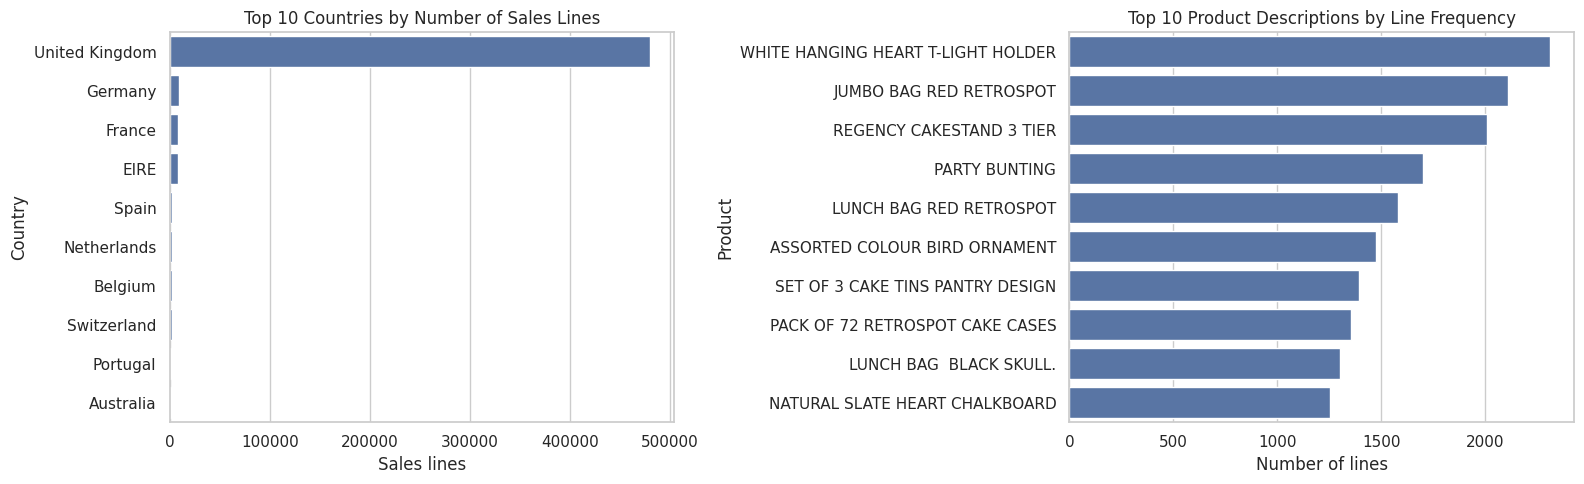

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_country_counts = sales["Country"].value_counts().head(10)
sns.barplot(x=top_country_counts.values, y=top_country_counts.index, ax=axes[0])
axes[0].set_title("Top 10 Countries by Number of Sales Lines")
axes[0].set_xlabel("Sales lines")
axes[0].set_ylabel("Country")

top_product_counts = sales["Description"].value_counts().head(10)
sns.barplot(x=top_product_counts.values, y=top_product_counts.index, ax=axes[1])
axes[1].set_title("Top 10 Product Descriptions by Line Frequency")
axes[1].set_xlabel("Number of lines")
axes[1].set_ylabel("Product")

plt.tight_layout()
plt.show()

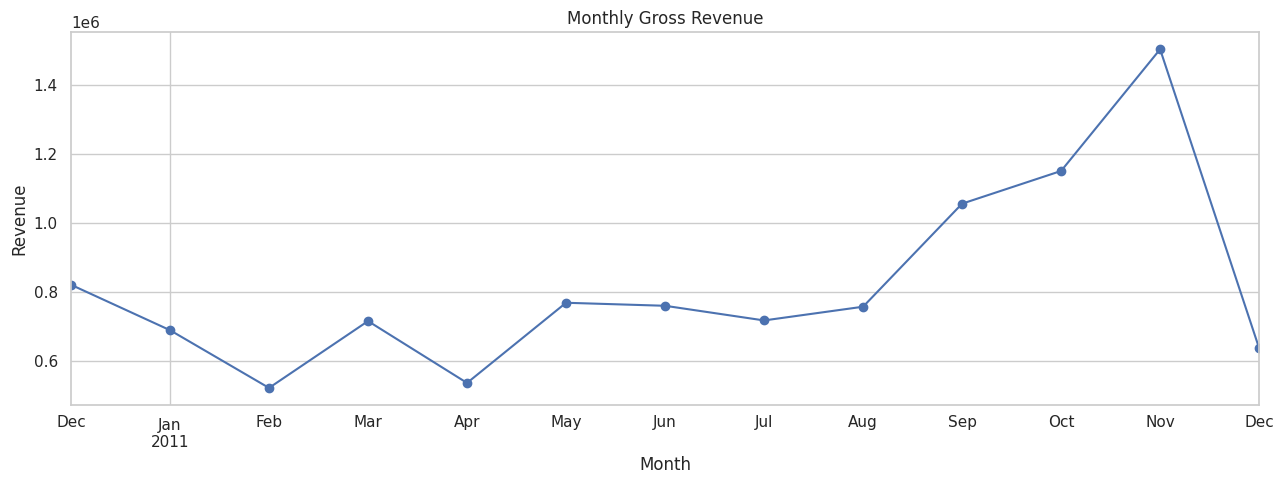

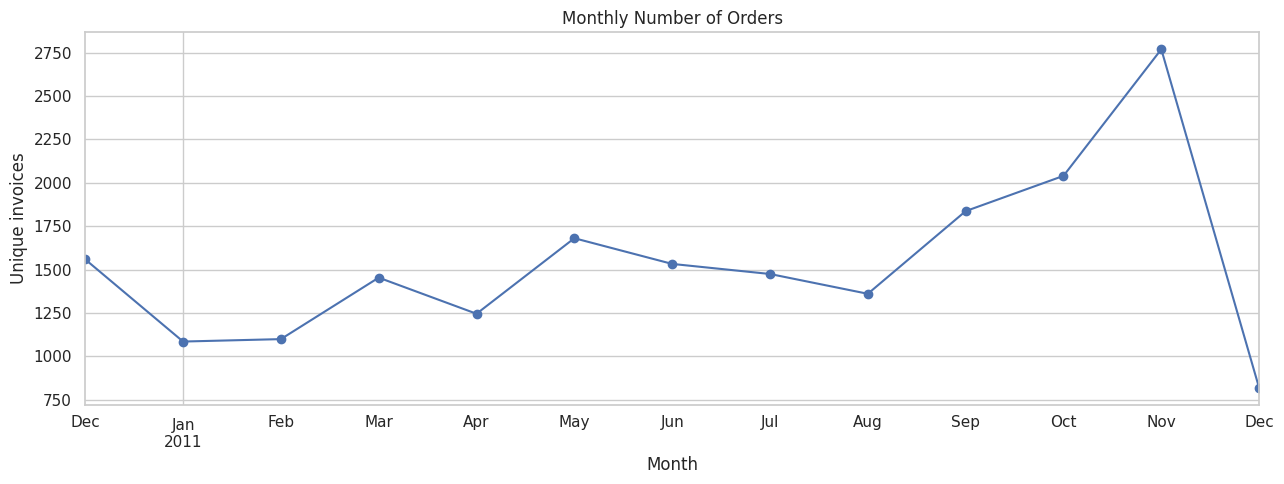

,Revenue,Units,Orders
InvoiceDate,,,
2010-12-01,821452.730,358019,1559
2011-01-01,689811.610,387099,1086
2011-02-01,522545.560,282934,1100
2011-03-01,716215.260,376599,1454
2011-04-01,536968.491,307953,1246
2011-05-01,769296.610,395001,1681
2011-06-01,760547.010,388511,1533
2011-07-01,718076.121,399693,1475
2011-08-01,757841.380,421020,1361


In [42]:
monthly = sales.set_index("InvoiceDate").resample("MS").agg(
    Revenue=("Revenue", "sum"),
    Units=("Quantity", "sum"),
    Orders=("InvoiceNo", "nunique")
)

fig, ax = plt.subplots(figsize=(13, 5))
monthly["Revenue"].plot(ax=ax, marker="o")
ax.set_title("Monthly Gross Revenue")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 5))
monthly["Orders"].plot(ax=ax, marker="o")
ax.set_title("Monthly Number of Orders")
ax.set_xlabel("Month")
ax.set_ylabel("Unique invoices")
plt.tight_layout()
plt.show()

display(monthly)

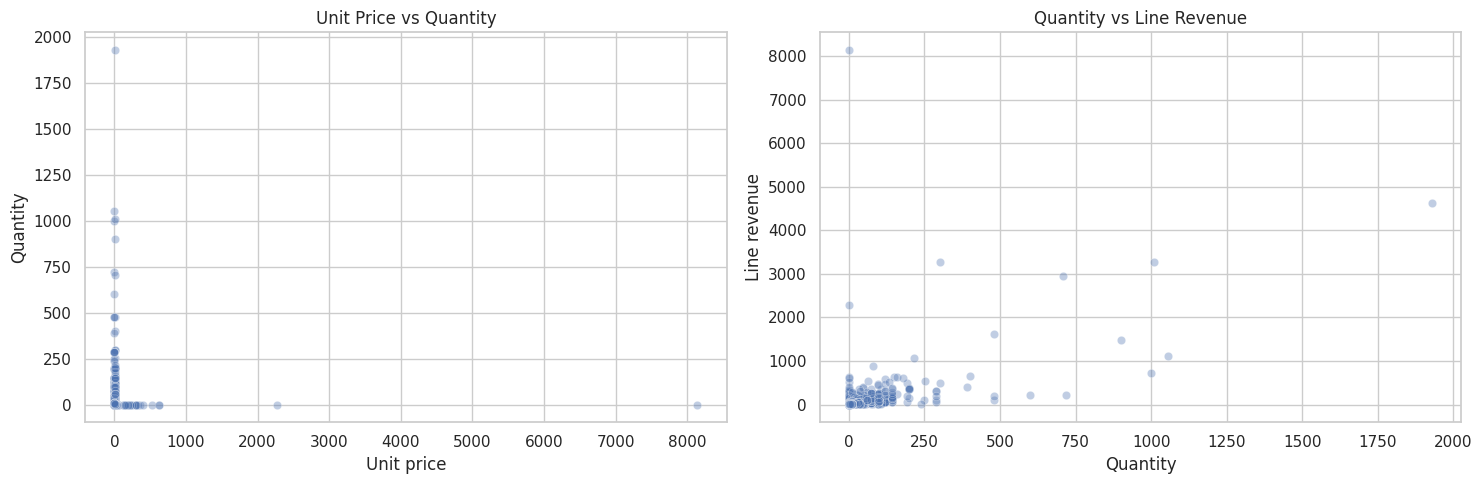

In [44]:
sample = sales.sample(n=min(8000, len(sales)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=sample, x="UnitPrice", y="Quantity", alpha=0.35, ax=axes[0])
axes[0].set_title("Unit Price vs Quantity")
axes[0].set_xlabel("Unit price")
axes[0].set_ylabel("Quantity")

sns.scatterplot(data=sample, x="Quantity", y="Revenue", alpha=0.35, ax=axes[1])
axes[1].set_title("Quantity vs Line Revenue")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Line revenue")

plt.tight_layout()
plt.show()

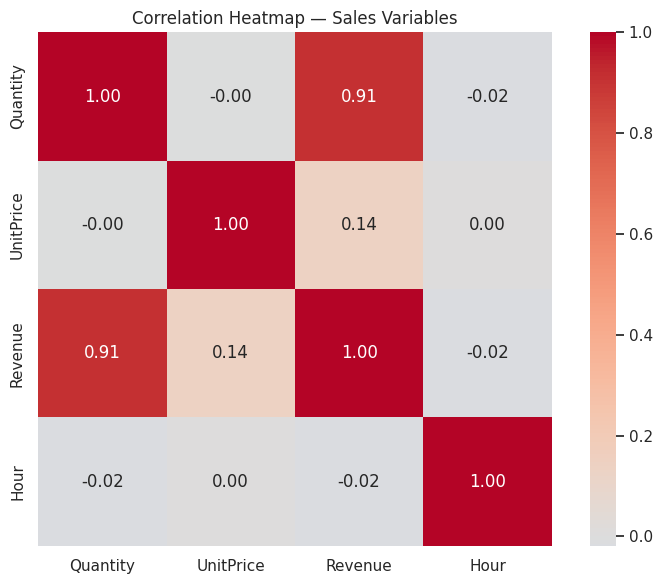

,Quantity,UnitPrice,Revenue,Hour
Quantity,1.000,-0.004,0.907,-0.019
UnitPrice,-0.004,1.000,0.137,0.004
Revenue,0.907,0.137,1.000,-0.016
Hour,-0.019,0.004,-0.016,1.000


In [45]:
numeric_columns = ["Quantity", "UnitPrice", "Revenue", "Hour"]
corr_data = sales[numeric_columns].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Sales Variables")
plt.tight_layout()
plt.show()

display(corr_data.corr().round(3))

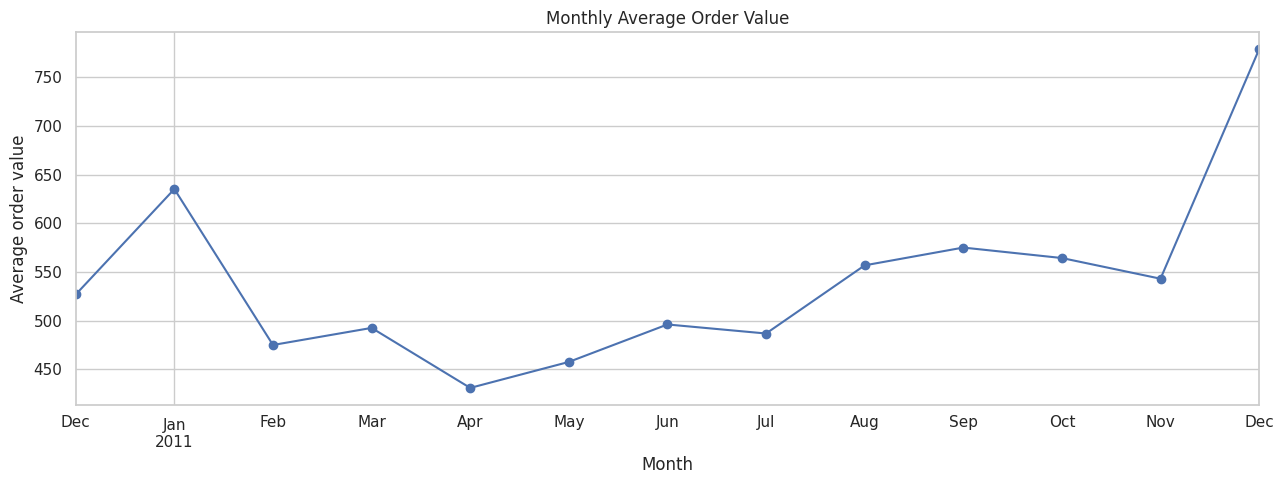

In [46]:
monthly_order_value = (
    sales.groupby(["YearMonth", "InvoiceNo"])["Revenue"].sum()
    .groupby("YearMonth").mean()
)
monthly_order_value.index = pd.PeriodIndex(monthly_order_value.index, freq="M").to_timestamp()

plt.figure(figsize=(13, 5))
monthly_order_value.plot(marker="o")
plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average order value")
plt.tight_layout()
plt.show()

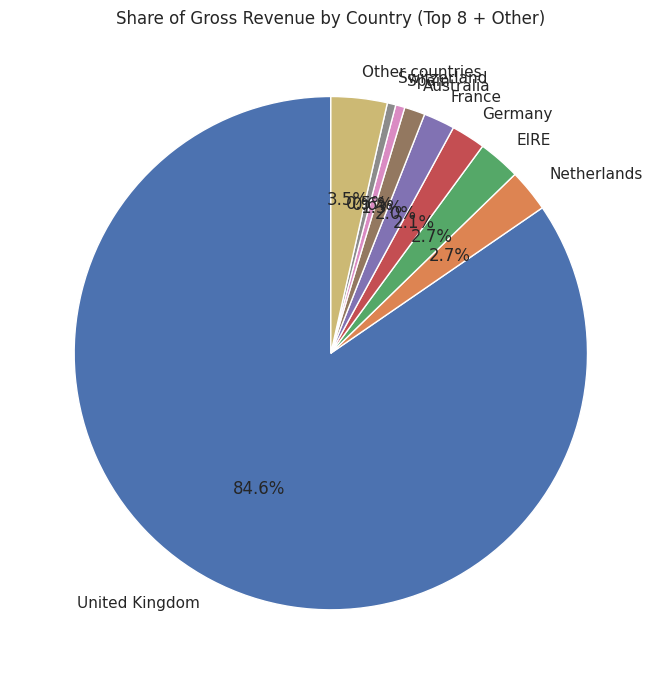

,Revenue share (%)
Country,
United Kingdom,84.59
Netherlands,2.68
EIRE,2.66
Germany,2.15
France,1.97
Australia,1.30
Spain,0.58
Switzerland,0.54
Belgium,0.39


In [47]:
country_share = (country_revenue / country_revenue.sum() * 100).sort_values(ascending=False)
top_share = country_share.head(8)
other_share = country_share.iloc[8:].sum()
share_plot = pd.concat([top_share, pd.Series({"Other countries": other_share})])

plt.figure(figsize=(9, 7))
plt.pie(share_plot.values, labels=share_plot.index, autopct="%1.1f%%", startangle=90)
plt.title("Share of Gross Revenue by Country (Top 8 + Other)")
plt.tight_layout()
plt.show()

display(country_share.head(15).rename("Revenue share (%)").to_frame().assign(
    **{"Revenue share (%)": lambda x: x["Revenue share (%)"].round(2)}
))

Top 10 customers by revenue:


,Revenue,Orders,Units,LastPurchase
CustomerID,,,,
14646.0,280206.02,73,196915,2011-12-08 12:12:00
18102.0,259657.30,60,64124,2011-12-09 11:50:00
17450.0,194390.79,46,69973,2011-12-01 13:29:00
16446.0,168472.50,2,80997,2011-12-09 09:15:00
14911.0,143711.17,201,80240,2011-12-08 15:54:00
12415.0,124914.53,21,77374,2011-11-15 14:22:00
14156.0,117210.08,55,57768,2011-11-30 10:54:00
17511.0,91062.38,31,64549,2011-12-07 10:12:00
16029.0,80850.84,63,40108,2011-11-01 10:27:00


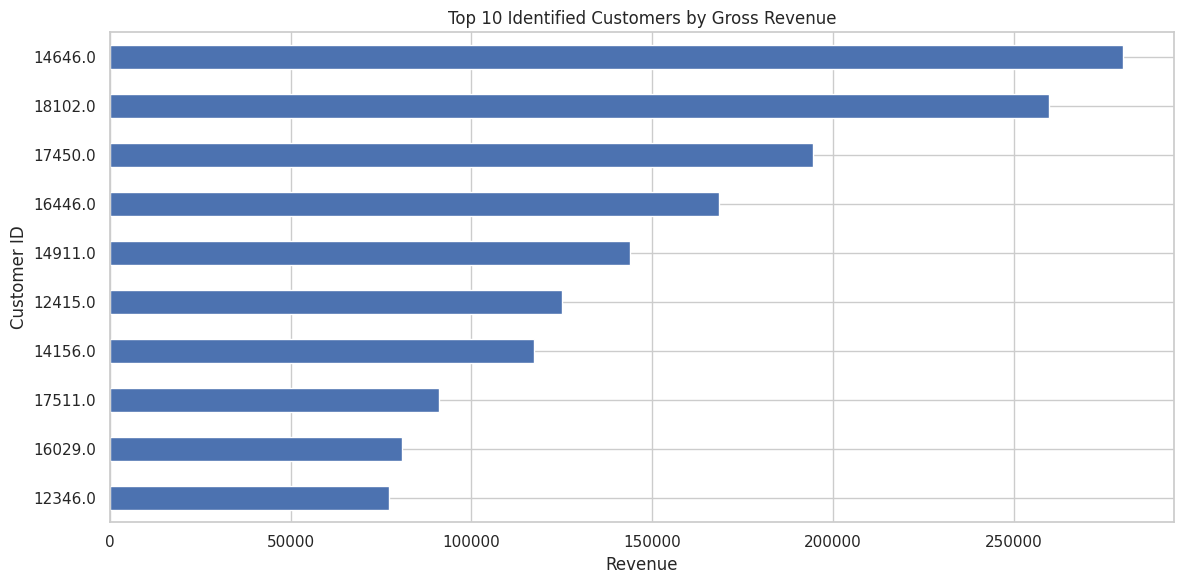

Customer summary statistics:


,count,mean,std,min,25%,50%,75%,max
Revenue,4338.0,2048.688081,8985.230220,3.75,306.482500,668.57,1660.597500,280206.02
Orders,4338.0,4.272015,7.697998,1.00,1.000000,2.00,5.000000,209.00
Units,4338.0,1187.644537,5043.619654,1.00,159.000000,378.00,989.750000,196915.00
AverageOrderValue,4338.0,417.645735,1796.511343,3.45,177.867083,291.94,428.280625,84236.25


In [48]:
if "CustomerID" in sales.columns:
    identified_sales = sales.dropna(subset=["CustomerID"]).copy()
    customer_summary = identified_sales.groupby("CustomerID").agg(
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Units=("Quantity", "sum"),
        LastPurchase=("InvoiceDate", "max")
    ).sort_values("Revenue", ascending=False)

    print("Top 10 customers by revenue:")
    display(customer_summary.head(10))

    plt.figure(figsize=(12, 6))
    customer_summary["Revenue"].head(10).sort_values().plot(kind="barh")
    plt.title("Top 10 Identified Customers by Gross Revenue")
    plt.xlabel("Revenue")
    plt.ylabel("Customer ID")
    plt.tight_layout()
    plt.show()

    customer_summary["AverageOrderValue"] = customer_summary["Revenue"] / customer_summary["Orders"]
    print("Customer summary statistics:")
    display(customer_summary[["Revenue", "Orders", "Units", "AverageOrderValue"]].describe().T)
else:
    print("CustomerID column unavailable; customer-level analysis skipped.")

Cancelled lines as % of cleaned lines: 1.72%
Cancelled invoices as % of unique invoices: 14.81%
Lines with negative quantity (potential returns/adjustments): 10,587
Revenue sum of negative-quantity lines (interpret carefully): -893,979.73


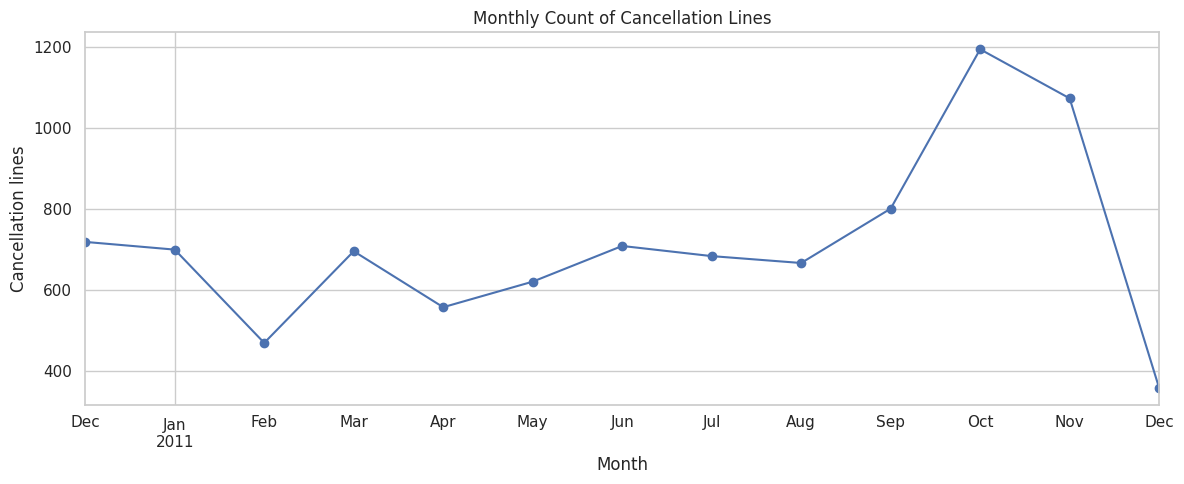

In [49]:
# Cancellation line rate and cancellation invoice rate
cancelled_lines = df[df["IsCancelled"]]
all_lines = len(df)
line_cancellation_rate = len(cancelled_lines) / all_lines * 100 if all_lines else np.nan

cancelled_invoice_count = cancelled_lines["InvoiceNo"].nunique()
all_invoice_count = df["InvoiceNo"].nunique()
invoice_cancellation_rate = cancelled_invoice_count / all_invoice_count * 100 if all_invoice_count else np.nan

negative_quantity_lines = df[df["Quantity"] < 0]
negative_quantity_value = negative_quantity_lines["Revenue"].sum()

print(f"Cancelled lines as % of cleaned lines: {line_cancellation_rate:.2f}%")
print(f"Cancelled invoices as % of unique invoices: {invoice_cancellation_rate:.2f}%")
print(f"Lines with negative quantity (potential returns/adjustments): {len(negative_quantity_lines):,}")
print(f"Revenue sum of negative-quantity lines (interpret carefully): {negative_quantity_value:,.2f}")

if len(cancelled_lines):
    cancelled_by_month = cancelled_lines.set_index("InvoiceDate").resample("MS")["InvoiceNo"].count()
    plt.figure(figsize=(12, 5))
    cancelled_by_month.plot(marker="o")
    plt.title("Monthly Count of Cancellation Lines")
    plt.xlabel("Month")
    plt.ylabel("Cancellation lines")
    plt.tight_layout()
    plt.show()

Pearson correlation between unit price and quantity: -0.004


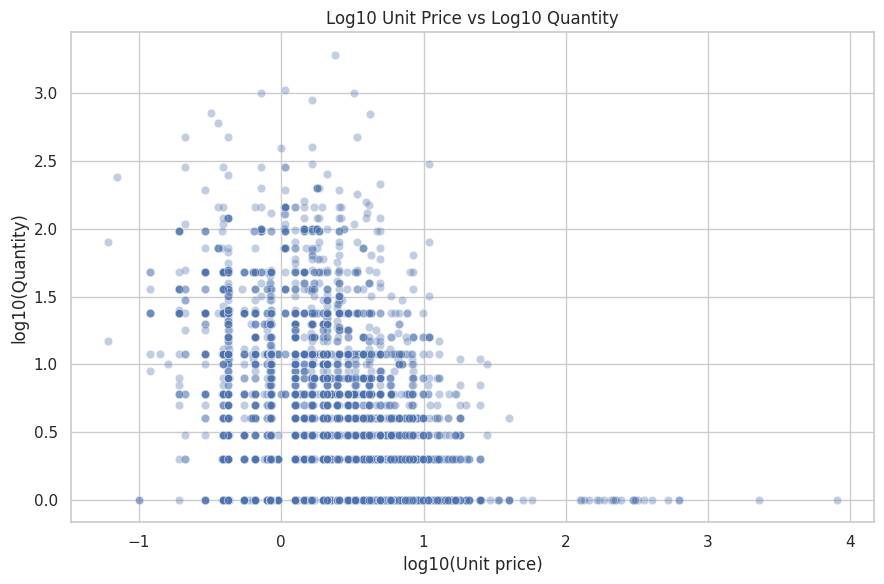

In [52]:
price_quantity_corr = sales[["UnitPrice", "Quantity"]].corr().iloc[0, 1]
print(f"Pearson correlation between unit price and quantity: {price_quantity_corr:.3f}")

positive_xy = sales.loc[(sales["UnitPrice"] > 0) & (sales["Quantity"] > 0), ["UnitPrice", "Quantity"]].copy()
positive_xy["log10_price"] = np.log10(positive_xy["UnitPrice"])
positive_xy["log10_quantity"] = np.log10(positive_xy["Quantity"])

plt.figure(figsize=(9, 6))
sns.scatterplot(data=positive_xy.sample(n=min(8000, len(positive_xy)), random_state=42),
                x="log10_price", y="log10_quantity", alpha=0.35)
plt.title("Log10 Unit Price vs Log10 Quantity")
plt.xlabel("log10(Unit price)")
plt.ylabel("log10(Quantity)")
plt.tight_layout()
plt.show()

In [53]:
print(" EDA SUMMARY ")
print(f"Sales rows analyzed: {len(sales):,}")
print(f"Unique orders: {sales['InvoiceNo'].nunique():,}")
if "CustomerID" in sales.columns:
    print(f"Identified customers: {sales['CustomerID'].nunique():,}")
print(f"Gross sales revenue: {sales['Revenue'].sum():,.2f}")
print(f"Units sold: {sales['Quantity'].sum():,.0f}")
print(f"Average order value: {sales.groupby('InvoiceNo')['Revenue'].sum().mean():,.2f}")

print("\nTop country by revenue:")
print(f"{country_revenue.index[0]} — {country_revenue.iloc[0]:,.2f}")

if len(product_revenue):
    print("\nTop product description by revenue:")
    print(f"{product_revenue.index[0]} — {product_revenue.iloc[0]:,.2f}")

print("\nHighest revenue month:")
print(f"{monthly['Revenue'].idxmax():%Y-%m} — {monthly['Revenue'].max():,.2f}")

print("\nRemember: these are descriptive findings. They do not establish causation.")

========== EDA SUMMARY ==========
Sales rows analyzed: 524,878
Unique orders: 19,960
Identified customers: 4,338
Gross sales revenue: 10,642,110.80
Units sold: 5,572,420
Average order value: 533.17

Top country by revenue:
United Kingdom — 9,001,744.09

Top product description by revenue:
DOTCOM POSTAGE — 206,248.77

Highest revenue month:
2011-11 — 1,503,866.78

Remember: these are descriptive findings. They do not establish causation.


In [57]:
from pathlib import Path

OUTPUT_DIR = Path("/content/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

kpis.to_csv(OUTPUT_DIR / "kpi_summary.csv", index=False)

monthly.to_csv(
    OUTPUT_DIR / "monthly_sales_summary.csv"
)

country_revenue.rename("Revenue").to_csv(
    OUTPUT_DIR / "country_revenue.csv"
)

if "CustomerID" in sales.columns:
    customer_summary.to_csv(
        OUTPUT_DIR / "customer_summary.csv"
    )

print("All summary files saved successfully!")
print("Output directory:", OUTPUT_DIR)

All summary files saved successfully!
Output directory: /content/outputs
